# Phase 1 - Exploratory Data Analysis

This notebook analyzes the Home Credit application dataset for the Credit Default Risk project.

The goal is to understand the dataset before modeling: how many records it has, whether the target is imbalanced, which columns have missing values, which applicant groups default more often, and which numeric columns contain suspicious values or outliers.

## Notebook Roadmap

1. Load the application dataset.
2. Check dataset size, primary key uniqueness, and target completeness.
3. Analyze the target variable.
4. Inspect missing values and data types.
5. Compare default rates across categorical groups.
6. Compare numeric variables between `TARGET = 0` and `TARGET = 1`.
7. Convert confusing day-based columns into readable year-based columns.
8. Inspect numeric distributions and outliers with clearer plots.
9. Save reusable Phase 1 output files.

In [38]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = "D:/DataScience_project/SCB_intern_project/outputs/applications_dataset.csv"
OUTPUT_DIR = Path("D:/DataScience_project/SCB_intern_project/outputs/phase_1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "TARGET"
ID_COLUMN = "SK_ID_CURR"

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

#if not DATA_PATH.exists():
 #   raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

## Load Data

`applications_dataset.csv` contains one row per loan application.

- `SK_ID_CURR` is the unique application/applicant ID.
- `TARGET = 0` means the applicant repaid normally.
- `TARGET = 1` means the applicant had repayment difficulties.

Set `SAMPLE_ROWS` to a number such as `5000` if you want a faster test run. Keep it as `None` for the full dataset.

In [39]:
SAMPLE_ROWS = None

df = pd.read_csv(DATA_PATH, nrows=SAMPLE_ROWS)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 307,511
Columns: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## Quick ID and Target Check

This cell displays only the ID and target columns. It helps confirm that every row has a traceable applicant/application ID and a target label for supervised learning.

In [40]:
df[[ID_COLUMN, TARGET]].head()

,SK_ID_CURR,TARGET
0,100002,1
1,100003,0
2,100004,0
3,100006,0
4,100007,0


## Dataset Overview

This is a basic health check for the dataset.

Important things to look for:

- Duplicate rows should be `0`.
- Duplicate `SK_ID_CURR` should be `0`, because it is the application ID.
- Missing target values should be `0`, because the target is required for supervised learning.

In [41]:
overview = pd.DataFrame(
    [
        ("rows", len(df)),
        ("columns", len(df.columns)),
        ("duplicate_rows", int(df.duplicated().sum())),
        ("duplicate_sk_id_curr", int(df[ID_COLUMN].duplicated().sum())),
        ("target_missing", int(df[TARGET].isna().sum())),
        ("numeric_columns", int(df.select_dtypes(include="number").shape[1])),
        ("categorical_columns", int(df.select_dtypes(exclude="number").shape[1])),
    ],
    columns=["metric", "value"],
)

overview.to_csv(OUTPUT_DIR / "dataset_overview.csv", index=False)
overview

,metric,value
0,rows,307511
1,columns,122
2,duplicate_rows,0
3,duplicate_sk_id_curr,0
4,target_missing,0
5,numeric_columns,106
6,categorical_columns,16


## Target Distribution and Class Imbalance

This checks how many applicants repaid normally versus how many had repayment difficulties.

This matters because credit default datasets are usually imbalanced. If only a small percentage default, a model can look accurate while still failing to identify risky applicants.

,TARGET,count,share
0,0,282686,0.919271
1,1,24825,0.080729


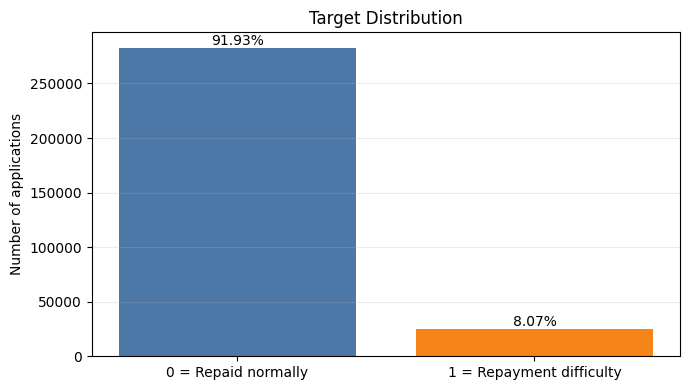

In [42]:
target_distribution = df[TARGET].value_counts(dropna=False).rename_axis(TARGET).reset_index(name="count")
target_distribution["share"] = target_distribution["count"] / len(df)
target_distribution.to_csv(OUTPUT_DIR / "target_distribution.csv", index=False)

display(target_distribution)

fig, ax = plt.subplots(figsize=(7, 4))
labels = target_distribution[TARGET].map({0: "0 = Repaid normally", 1: "1 = Repayment difficulty"}).astype(str)
ax.bar(labels, target_distribution["count"], color=["#4C78A8", "#F58518"])
ax.set_title("Target Distribution")
ax.set_ylabel("Number of applications")
ax.grid(axis="y", alpha=0.25)
for index, row in target_distribution.iterrows():
    ax.text(index, row["count"], f"{row['share']:.2%}", ha="center", va="bottom")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Data Types and Missing Values

This section answers two questions:

1. Which columns are numeric and which are categorical?
2. Which columns have missing values?

High missingness is important because it affects Phase 2 cleaning. Some columns may need imputation, some may be dropped, and some missing values may carry useful information.

In [43]:
dtype_summary = df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="column_count")
dtype_summary

,dtype,column_count
0,float64,65
1,int64,41
2,object,16


In [44]:
missing_values = df.isna().sum().rename("missing_count").reset_index().rename(columns={"index": "column"})
missing_values["missing_rate"] = missing_values["missing_count"] / len(df)
missing_values["dtype"] = missing_values["column"].map(lambda column: str(df[column].dtype))
missing_values = missing_values.sort_values(["missing_rate", "missing_count"], ascending=False)
missing_values.to_csv(OUTPUT_DIR / "missing_values.csv", index=False)

columns_with_missing = int((missing_values["missing_count"] > 0).sum())
print(f"Columns with at least one missing value: {columns_with_missing} of {len(missing_values)}")
missing_values[missing_values["missing_count"] > 0].head(25)

Columns with at least one missing value: 67 of 122


,column,missing_count,missing_rate,dtype
48,COMMONAREA_AVG,214865,0.698723,float64
62,COMMONAREA_MODE,214865,0.698723,float64
76,COMMONAREA_MEDI,214865,0.698723,float64
56,NONLIVINGAPARTMENTS_AVG,213514,0.694330,float64
70,NONLIVINGAPARTMENTS_MODE,213514,0.694330,float64
84,NONLIVINGAPARTMENTS_MEDI,213514,0.694330,float64
86,FONDKAPREMONT_MODE,210295,0.683862,object
54,LIVINGAPARTMENTS_AVG,210199,0.683550,float64
68,LIVINGAPARTMENTS_MODE,210199,0.683550,float64
82,LIVINGAPARTMENTS_MEDI,210199,0.683550,float64


## Categorical Default Rates

Categorical columns describe groups, such as gender, education type, income type, occupation, and housing type.

For each group, this table calculates:

- `application_count`: how many applicants are in that group.
- `default_rate`: the percentage of that group with `TARGET = 1`.

Large groups with high default rates are more reliable risk signals. Very small groups can have unstable rates, so interpret them carefully.

In [45]:
key_categorical_columns = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

categorical_tables = []
for column in key_categorical_columns:
    if column not in df.columns:
        continue
    grouped = (
        df.groupby(column, dropna=False)[TARGET]
        .agg(application_count="size", default_rate="mean")
        .reset_index()
        .rename(columns={column: "category_value"})
    )
    grouped.insert(0, "column", column)
    categorical_tables.append(grouped.sort_values("application_count", ascending=False).head(20))

categorical_default_rates = pd.concat(categorical_tables, ignore_index=True)
categorical_default_rates.to_csv(OUTPUT_DIR / "categorical_default_rates.csv", index=False)
categorical_default_rates.head(40)

,column,category_value,application_count,default_rate
0,NAME_CONTRACT_TYPE,Cash loans,278232,0.083459
1,NAME_CONTRACT_TYPE,Revolving loans,29279,0.054783
2,CODE_GENDER,F,202448,0.069993
3,CODE_GENDER,M,105059,0.101419
4,CODE_GENDER,XNA,4,0.000000
5,FLAG_OWN_CAR,N,202924,0.085002
6,FLAG_OWN_CAR,Y,104587,0.072437
7,FLAG_OWN_REALTY,Y,213312,0.079616
8,FLAG_OWN_REALTY,N,94199,0.083249
9,NAME_INCOME_TYPE,Working,158774,0.095885


## Numeric Analysis by Target

This compares important numeric columns between the two target groups.

For example, it compares average/median income for:

- `TARGET = 0`: applicants who repaid normally.
- `TARGET = 1`: applicants who had repayment difficulties.

If a numeric column has very different values across the two target groups, it may be useful for predicting default risk.

In [46]:
key_numeric_columns = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "REGION_RATING_CLIENT",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

rows = []
for column in key_numeric_columns:
    if column not in df.columns:
        continue
    for target_value, group in df.groupby(TARGET):
        values = group[column].dropna()
        rows.append(
            {
                "column": column,
                "target": target_value,
                "count": int(values.count()),
                "mean": float(values.mean()) if not values.empty else None,
                "median": float(values.median()) if not values.empty else None,
                "min": float(values.min()) if not values.empty else None,
                "max": float(values.max()) if not values.empty else None,
            }
        )

numeric_default_summary = pd.DataFrame(rows)
numeric_default_summary.to_csv(OUTPUT_DIR / "numeric_default_summary.csv", index=False)
numeric_default_summary

,column,target,count,mean,median,min,max
0,AMT_INCOME_TOTAL,0,282686,169077.722266,148500.000000,2.565000e+04,1.800009e+07
1,AMT_INCOME_TOTAL,1,24825,165611.760906,135000.000000,2.565000e+04,1.170000e+08
2,AMT_CREDIT,0,282686,602648.282002,517788.000000,4.500000e+04,4.050000e+06
3,AMT_CREDIT,1,24825,557778.527674,497520.000000,4.500000e+04,4.027680e+06
4,AMT_ANNUITY,0,282674,27163.623349,24876.000000,1.615500e+03,2.580255e+05
5,AMT_ANNUITY,1,24825,26481.744290,25263.000000,2.722500e+03,1.492110e+05
6,AMT_GOODS_PRICE,0,282429,542736.795003,450000.000000,4.050000e+04,4.050000e+06
7,AMT_GOODS_PRICE,1,24804,488972.412554,450000.000000,4.500000e+04,3.600000e+06
8,DAYS_BIRTH,0,282686,-16138.176397,-15877.000000,-2.522900e+04,-7.489000e+03
9,DAYS_BIRTH,1,24825,-14884.828077,-14282.000000,-2.516800e+04,-7.678000e+03


## Numeric Distributions After Converting Day Columns

Some Home Credit columns store dates as negative numbers of days before the application date. That format is hard to read.

This section converts those columns into years for inspection:

- `DAYS_BIRTH` becomes `AGE_YEARS`.
- `DAYS_EMPLOYED` becomes `EMPLOYMENT_YEARS`.
- `DAYS_REGISTRATION` becomes `REGISTRATION_YEARS_BEFORE_APPLICATION`.
- `DAYS_ID_PUBLISH` becomes `ID_PUBLISH_YEARS_BEFORE_APPLICATION`.
- `DAYS_LAST_PHONE_CHANGE` becomes `PHONE_CHANGE_YEARS_BEFORE_APPLICATION`.

It also handles the known `DAYS_EMPLOYED = 365243` anomaly by replacing it with missing in the inspection copy and keeping a flag.

In [47]:
distribution_df = df.copy()

day_columns_to_years = {
    "DAYS_BIRTH": "AGE_YEARS",
    "DAYS_EMPLOYED": "EMPLOYMENT_YEARS",
    "DAYS_REGISTRATION": "REGISTRATION_YEARS_BEFORE_APPLICATION",
    "DAYS_ID_PUBLISH": "ID_PUBLISH_YEARS_BEFORE_APPLICATION",
    "DAYS_LAST_PHONE_CHANGE": "PHONE_CHANGE_YEARS_BEFORE_APPLICATION",
}

if "DAYS_EMPLOYED" in distribution_df.columns:
    distribution_df["DAYS_EMPLOYED_365243_FLAG"] = (distribution_df["DAYS_EMPLOYED"] == 365243).astype(int)
    distribution_df.loc[distribution_df["DAYS_EMPLOYED"] == 365243, "DAYS_EMPLOYED"] = pd.NA

for source_column, new_column in day_columns_to_years.items():
    if source_column in distribution_df.columns:
        distribution_df[new_column] = (-distribution_df[source_column] / 365.25).clip(lower=0)

year_columns = [column for column in day_columns_to_years.values() if column in distribution_df.columns]
distribution_df[year_columns].head()

,AGE_YEARS,EMPLOYMENT_YEARS,REGISTRATION_YEARS_BEFORE_APPLICATION,ID_PUBLISH_YEARS_BEFORE_APPLICATION,PHONE_CHANGE_YEARS_BEFORE_APPLICATION
0,25.902806,1.744011,9.987680,5.804244,3.104723
1,45.900068,3.252567,3.247091,0.796715,2.266940
2,52.145106,0.616016,11.663244,6.929500,2.231348
3,52.032854,8.320329,26.921287,6.672142,1.689254
4,54.570842,8.317591,11.802875,9.467488,3.028063


## Numeric Distribution Table

This table summarizes every numeric column after the readable year columns are added.

Important columns:

- `missing_rate`: percentage of rows where the value is missing.
- `zero_rate`: percentage of rows where the value is exactly zero.
- `p01`, `p05`, `p95`, `p99`: percentiles used to spot extreme values.
- `max`: the largest value in the column.

A useful outlier check is to compare `p99` with `max`. If `max` is much larger than `p99`, there may be extreme outliers.

In [48]:
numeric_base = distribution_df.select_dtypes(include="number")

numeric_distribution = numeric_base.agg(["count", "mean", "std", "min", "median", "max"]).T.reset_index().rename(columns={"index": "column"})
percentiles = numeric_base.quantile([0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).T.reset_index().rename(
    columns={
        "index": "column",
        0.01: "p01",
        0.05: "p05",
        0.25: "p25",
        0.75: "p75",
        0.95: "p95",
        0.99: "p99",
    }
)

numeric_distribution = numeric_distribution.merge(percentiles, on="column", how="left")
numeric_distribution["missing_count"] = numeric_distribution["column"].map(distribution_df.isna().sum())
numeric_distribution["missing_rate"] = numeric_distribution["missing_count"] / len(distribution_df)
numeric_distribution["zero_count"] = numeric_distribution["column"].map(lambda column: int((distribution_df[column] == 0).sum()))
numeric_distribution["zero_rate"] = numeric_distribution["zero_count"] / len(distribution_df)

ordered_columns = [
    "column", "count", "missing_count", "missing_rate", "zero_count", "zero_rate",
    "mean", "std", "min", "p01", "p05", "p25", "median", "p75", "p95", "p99", "max",
]
numeric_distribution = numeric_distribution[ordered_columns].sort_values("column")
numeric_distribution.to_csv(OUTPUT_DIR / "numeric_distribution_after_year_conversion.csv", index=False)
numeric_distribution.head(30)

,column,count,missing_count,missing_rate,zero_count,zero_rate,mean,std,min,p01,p05,p25,median,p75,p95,p99,max
107,AGE_YEARS,307511.0,0,0.000000,0,0.000000,43.906900,11.947950,20.503765,22.622861,25.754962,33.984942,43.12115,53.886379,6.352909e+01,6.685558e+01,6.907324e+01
5,AMT_ANNUITY,307499.0,12,0.000039,0,0.000000,27108.573909,14493.737315,1615.500000,6182.910000,9000.000000,16524.000000,24903.00000,34596.000000,5.332500e+04,7.000650e+04,2.580255e+05
4,AMT_CREDIT,307511.0,0,0.000000,0,0.000000,599025.999706,402490.776996,45000.000000,76410.000000,135000.000000,270000.000000,513531.00000,808650.000000,1.350000e+06,1.854000e+06,4.050000e+06
6,AMT_GOODS_PRICE,307233.0,278,0.000904,0,0.000000,538396.207429,369446.460540,40500.000000,67500.000000,135000.000000,238500.000000,450000.00000,679500.000000,1.305000e+06,1.800000e+06,4.050000e+06
3,AMT_INCOME_TOTAL,307511.0,0,0.000000,0,0.000000,168797.919297,237123.146279,25650.000000,45000.000000,67500.000000,112500.000000,147150.00000,202500.000000,3.375000e+05,4.725000e+05,1.170000e+08
101,AMT_REQ_CREDIT_BUREAU_DAY,265992.0,41519,0.135016,264503,0.860142,0.007000,0.110757,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000e+00,0.000000e+00,9.000000e+00
100,AMT_REQ_CREDIT_BUREAU_HOUR,265992.0,41519,0.135016,264366,0.859696,0.006402,0.083849,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000e+00,0.000000e+00,4.000000e+00
103,AMT_REQ_CREDIT_BUREAU_MON,265992.0,41519,0.135016,222233,0.722683,0.267395,0.916002,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000e+00,4.000000e+00,2.700000e+01
104,AMT_REQ_CREDIT_BUREAU_QRT,265992.0,41519,0.135016,215417,0.700518,0.265474,0.794056,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2.000000e+00,2.000000e+00,2.610000e+02
102,AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,41519,0.135016,257456,0.837225,0.034362,0.204685,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000e+00,1.000000e+00,8.000000e+00


In [49]:
# Columns with the highest missing rates after conversion.
numeric_distribution.sort_values("missing_rate", ascending=False).head(30)

,column,count,missing_count,missing_rate,zero_count,zero_rate,mean,std,min,p01,p05,p25,median,p75,p95,p99,max
64,COMMONAREA_MEDI,92646.0,214865,0.698723,8691,0.028262,0.044595,0.076144,0.000000,0.000000,0.000000,0.007900,0.020800,0.051300,0.16090,0.378555,1.000000
50,COMMONAREA_MODE,92646.0,214865,0.698723,9690,0.031511,0.042553,0.074445,0.000000,0.000000,0.000000,0.007200,0.019000,0.049000,0.15320,0.365555,1.000000
36,COMMONAREA_AVG,92646.0,214865,0.698723,8442,0.027453,0.044621,0.076036,0.000000,0.000000,0.000000,0.007800,0.021100,0.051500,0.16010,0.376555,1.000000
58,NONLIVINGAPARTMENTS_MODE,93997.0,213514,0.694330,59255,0.192692,0.008076,0.046276,0.000000,0.000000,0.000000,0.000000,0.000000,0.003900,0.02720,0.097300,1.000000
72,NONLIVINGAPARTMENTS_MEDI,93997.0,213514,0.694330,56097,0.182423,0.008651,0.047415,0.000000,0.000000,0.000000,0.000000,0.000000,0.003900,0.03110,0.104800,1.000000
44,NONLIVINGAPARTMENTS_AVG,93997.0,213514,0.694330,54549,0.177389,0.008809,0.047732,0.000000,0.000000,0.000000,0.000000,0.000000,0.003900,0.03090,0.108100,1.000000
42,LIVINGAPARTMENTS_AVG,97312.0,210199,0.683550,418,0.001359,0.100775,0.092576,0.000000,0.003400,0.010100,0.050400,0.075600,0.121000,0.27230,0.453900,1.000000
56,LIVINGAPARTMENTS_MODE,97312.0,210199,0.683550,519,0.001688,0.105645,0.097880,0.000000,0.002800,0.011000,0.054200,0.077100,0.131300,0.29480,0.488500,1.000000
70,LIVINGAPARTMENTS_MEDI,97312.0,210199,0.683550,433,0.001408,0.101954,0.093642,0.000000,0.003400,0.010300,0.051300,0.076100,0.123100,0.27700,0.461700,1.000000
40,FLOORSMIN_AVG,98869.0,208642,0.678486,2320,0.007544,0.231894,0.161380,0.000000,0.000000,0.041700,0.083300,0.208300,0.375000,0.50000,0.708300,1.000000


In [50]:
# Readable year-based columns only.
numeric_distribution[numeric_distribution["column"].isin(year_columns + ["DAYS_EMPLOYED_365243_FLAG"])].sort_values("column")

,column,count,missing_count,missing_rate,zero_count,zero_rate,mean,std,min,p01,p05,p25,median,p75,p95,p99,max
107,AGE_YEARS,307511.0,0,0.000000,0,0.000000,43.906900,11.947950,20.503765,22.622861,25.754962,33.984942,43.121150,53.886379,63.529090,66.855578,69.073238
106,DAYS_EMPLOYED_365243_FLAG,307511.0,0,0.000000,252137,0.819928,0.180072,0.384248,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
108,EMPLOYMENT_YEARS,252137.0,55374,0.180072,2,0.000007,6.527500,6.402081,-0.000000,0.303901,0.563997,2.099932,4.511978,8.692676,19.961670,31.042519,49.040383
110,ID_PUBLISH_YEARS_BEFORE_APPLICATION,307511.0,0,0.000000,16,0.000052,8.197679,4.132650,0.000000,0.167009,1.026694,4.709103,8.908966,11.770021,13.535934,14.913073,19.704312
111,PHONE_CHANGE_YEARS_BEFORE_APPLICATION,307510.0,1,0.000003,37672,0.122506,2.636164,2.263678,-0.000000,0.000000,0.000000,0.750171,2.072553,4.298426,6.904860,8.621492,11.750856
109,REGISTRATION_YEARS_BEFORE_APPLICATION,307511.0,0,0.000000,80,0.000260,13.651253,9.645137,-0.000000,0.136893,0.903491,5.503080,12.331280,20.477755,31.255305,37.998631,67.548255


## Children Count vs Family Members Count

This is a data-quality and business-logic check.

`CNT_CHILDREN` is the number of children. `CNT_FAM_MEMBERS` is the total family size. Usually, total family members should be at least children plus the applicant:

`CNT_FAM_MEMBERS >= CNT_CHILDREN + 1`

This section helps us inspect whether high child/family counts are real large-family cases or possible data issues. It belongs in EDA because we are only investigating the data, not creating model features yet.

In [56]:
if {"CNT_CHILDREN", "CNT_FAM_MEMBERS"}.issubset(df.columns):
    children_family_check = df[[ID_COLUMN, TARGET, "CNT_CHILDREN", "CNT_FAM_MEMBERS"]].copy()
    children_family_check["FAMILY_MINUS_CHILDREN"] = children_family_check["CNT_FAM_MEMBERS"] - children_family_check["CNT_CHILDREN"]
    children_family_check["FAMILY_LESS_THAN_CHILDREN_PLUS_APPLICANT"] = (
        children_family_check["CNT_FAM_MEMBERS"] < children_family_check["CNT_CHILDREN"] + 1
    )

    display(children_family_check[["CNT_CHILDREN", "CNT_FAM_MEMBERS", "FAMILY_MINUS_CHILDREN"]].describe())
    display(
        children_family_check["FAMILY_LESS_THAN_CHILDREN_PLUS_APPLICANT"]
        .value_counts(dropna=False)
        .rename_axis("family_count_issue")
        .reset_index(name="row_count")
    )
else:
    print("CNT_CHILDREN and/or CNT_FAM_MEMBERS not found in the dataset.")

,CNT_CHILDREN,CNT_FAM_MEMBERS,FAMILY_MINUS_CHILDREN
count,307511.000000,307509.000000,307509.000000
mean,0.417052,2.152665,1.735611
std,0.722121,0.910682,0.441008
min,0.000000,1.000000,1.000000
25%,0.000000,2.000000,1.000000
50%,0.000000,2.000000,2.000000
75%,1.000000,3.000000,2.000000
max,19.000000,20.000000,2.000000


,family_count_issue,row_count
0,False,307511


In [57]:
if "children_family_check" in globals():
    print("Rows with the largest child counts")
    display(children_family_check.sort_values("CNT_CHILDREN", ascending=False).head(15))

    print("Rows with the largest family member counts")
    display(children_family_check.sort_values("CNT_FAM_MEMBERS", ascending=False).head(15))

    print("Rows where family members are fewer than children plus applicant")
    display(children_family_check[children_family_check["FAMILY_LESS_THAN_CHILDREN_PLUS_APPLICANT"]].head(20))

Rows with the largest child counts


,SK_ID_CURR,TARGET,CNT_CHILDREN,CNT_FAM_MEMBERS,FAMILY_MINUS_CHILDREN,FAMILY_LESS_THAN_CHILDREN_PLUS_APPLICANT
265784,407877,0,19,20.0,1.0,False
155369,280108,0,19,20.0,1.0,False
267998,410527,0,14,16.0,2.0,False
183878,313127,0,14,16.0,2.0,False
176011,303956,0,14,15.0,1.0,False
171125,298322,0,12,14.0,2.0,False
80948,193853,0,12,14.0,2.0,False
34545,140032,1,11,13.0,2.0,False
132585,253779,0,10,12.0,2.0,False
186820,316580,0,10,12.0,2.0,False


Rows with the largest family member counts


,SK_ID_CURR,TARGET,CNT_CHILDREN,CNT_FAM_MEMBERS,FAMILY_MINUS_CHILDREN,FAMILY_LESS_THAN_CHILDREN_PLUS_APPLICANT
265784,407877,0,19,20.0,1.0,False
155369,280108,0,19,20.0,1.0,False
183878,313127,0,14,16.0,2.0,False
267998,410527,0,14,16.0,2.0,False
176011,303956,0,14,15.0,1.0,False
171125,298322,0,12,14.0,2.0,False
80948,193853,0,12,14.0,2.0,False
34545,140032,1,11,13.0,2.0,False
186820,316580,0,10,12.0,2.0,False
132585,253779,0,10,12.0,2.0,False


Rows where family members are fewer than children plus applicant


,SK_ID_CURR,TARGET,CNT_CHILDREN,CNT_FAM_MEMBERS,FAMILY_MINUS_CHILDREN,FAMILY_LESS_THAN_CHILDREN_PLUS_APPLICANT


### Insight and Value

This check tells us whether the child and family-size columns are internally consistent.

If high child counts also have high family member counts, they may be rare but valid large-family cases. If family members are fewer than children plus the applicant, the row may contain a data issue.

Best action: inspect these rows first. Do not cap or delete `CNT_CHILDREN` or `CNT_FAM_MEMBERS` automatically unless the relationship is clearly impossible or inconsistent.

## Outlier Inspection with Boxplots

The earlier numeric summary suggested a few likely outlier columns:

- `AMT_INCOME_TOTAL`: income has very large maximum values compared with typical values.
- `CNT_CHILDREN`: most applicants have few or no children, but a few rows are very high.
- `CNT_FAM_MEMBERS`: most families are small, but a few rows are very high.
- `EMPLOYMENT_YEARS`: after fixing `365243`, this checks whether employment length looks realistic.

The income plot uses a logarithmic x-axis because income is highly skewed. This makes the normal range and extreme values easier to see on the same chart.

The dashed orange line is the median. The dashed red line is the 99th percentile.

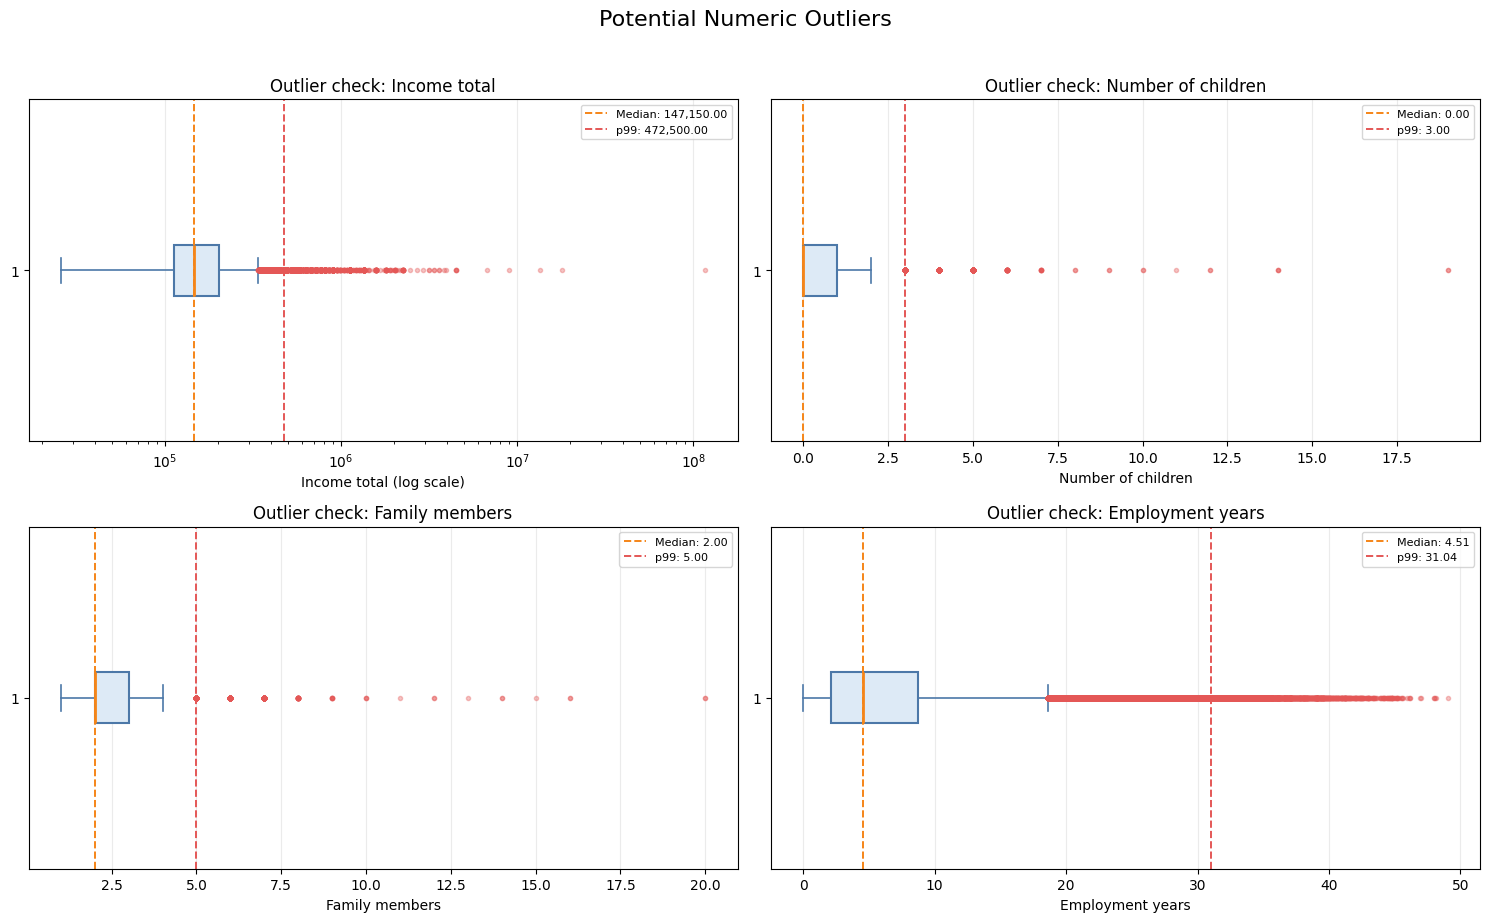

In [51]:
outlier_plot_specs = [
    ("AMT_INCOME_TOTAL", "Income total", True),
    ("CNT_CHILDREN", "Number of children", False),
    ("CNT_FAM_MEMBERS", "Family members", False),
    ("EMPLOYMENT_YEARS", "Employment years", False),
]

available_specs = [(column, label, use_log) for column, label, use_log in outlier_plot_specs if column in distribution_df.columns]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for axis, (column, label, use_log) in zip(axes, available_specs):
    values = distribution_df[column].dropna()
    axis.boxplot(
        values,
        vert=False,
        patch_artist=True,
        showfliers=True,
        boxprops={"facecolor": "#DDEAF6", "edgecolor": "#4C78A8", "linewidth": 1.5},
        medianprops={"color": "#F58518", "linewidth": 2},
        whiskerprops={"color": "#4C78A8", "linewidth": 1.2},
        capprops={"color": "#4C78A8", "linewidth": 1.2},
        flierprops={"marker": "o", "markerfacecolor": "#E45756", "markeredgecolor": "#E45756", "markersize": 3, "alpha": 0.35},
    )
    median_value = values.median()
    p99_value = values.quantile(0.99)
    axis.axvline(median_value, color="#F58518", linestyle="--", linewidth=1.4, label=f"Median: {median_value:,.2f}")
    axis.axvline(p99_value, color="#E45756", linestyle="--", linewidth=1.4, label=f"p99: {p99_value:,.2f}")
    if use_log and values[values > 0].size > 0:
        axis.set_xscale("log")
        axis.set_xlabel(f"{label} (log scale)")
    else:
        axis.set_xlabel(label)
    axis.set_title(f"Outlier check: {label}")
    axis.grid(axis="x", alpha=0.25)
    axis.legend(loc="best", fontsize=8)

for axis in axes[len(available_specs):]:
    axis.axis("off")

fig.suptitle("Potential Numeric Outliers", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Top Extreme Rows

The boxplots show the shape, but the tables below show the actual rows with the largest values.

Use these tables to decide whether a value is impossible, rare but valid, or something that needs business review.

In [52]:
for column in ["AMT_INCOME_TOTAL", "CNT_CHILDREN", "CNT_FAM_MEMBERS", "EMPLOYMENT_YEARS"]:
    if column in distribution_df.columns:
        display_columns = [ID_COLUMN, TARGET, column]
        print(f"Top values for {column}")
        display(distribution_df[display_columns].sort_values(column, ascending=False).head(10))

Top values for AMT_INCOME_TOTAL


,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL
12840,114967,1,117000000.0
203693,336147,0,18000090.0
246858,385674,0,13500000.0
77768,190160,0,9000000.0
131127,252084,0,6750000.0
103006,219563,0,4500000.0
204564,337151,0,4500000.0
187833,317748,0,4500000.0
287463,432980,0,4500000.0
181698,310601,0,3950059.5


Top values for CNT_CHILDREN


,SK_ID_CURR,TARGET,CNT_CHILDREN
265784,407877,0,19
155369,280108,0,19
267998,410527,0,14
183878,313127,0,14
176011,303956,0,14
171125,298322,0,12
80948,193853,0,12
34545,140032,1,11
132585,253779,0,10
186820,316580,0,10


Top values for CNT_FAM_MEMBERS


,SK_ID_CURR,TARGET,CNT_FAM_MEMBERS
265784,407877,0,20.0
155369,280108,0,20.0
183878,313127,0,16.0
267998,410527,0,16.0
176011,303956,0,15.0
171125,298322,0,14.0
80948,193853,0,14.0
34545,140032,1,13.0
186820,316580,0,12.0
132585,253779,0,12.0


Top values for EMPLOYMENT_YEARS


,SK_ID_CURR,TARGET,EMPLOYMENT_YEARS
280994,425566,0,49.040383
273069,416545,0,48.139630
208899,342112,0,48.038330
35191,140766,0,47.997262
234168,371247,0,47.972621
142446,265162,0,47.008898
143265,266124,0,46.924025
296917,443997,0,46.138261
39095,145275,0,46.130048
249164,388307,0,46.094456


## IQR Outlier Summary

This table uses the IQR rule to count possible outliers for every numeric column.

IQR means interquartile range:

`IQR = p75 - p25`

A common rule marks values as potential outliers if they are below `p25 - 1.5 * IQR` or above `p75 + 1.5 * IQR`.

This is a screening method, not a deletion rule. Some outliers are real business cases.

In [53]:
numeric_columns_for_outliers = distribution_df.select_dtypes(include="number").columns
outlier_rows = []

for column in numeric_columns_for_outliers:
    values = distribution_df[column].dropna()
    if values.empty:
        continue
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((values < lower_bound) | (values > upper_bound)).sum())
    outlier_rows.append(
        {
            "column": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_rate": outlier_count / len(distribution_df),
            "min": values.min(),
            "median": values.median(),
            "max": values.max(),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_rate", ascending=False)
outlier_summary.to_csv(OUTPUT_DIR / "numeric_outlier_summary.csv", index=False)
outlier_summary.head(30)

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate,min,median,max
20,REGION_RATING_CLIENT,2.000000,2.000000,0.000000,2.000000,2.000000e+00,80527,0.261867,1.0,2.000000,3.000000e+00
21,REGION_RATING_CLIENT_W_CITY,2.000000,2.000000,0.000000,2.000000,2.000000e+00,78027,0.253737,1.0,2.000000,3.000000e+00
27,REG_CITY_NOT_WORK_CITY,0.000000,0.000000,0.000000,0.000000,0.000000e+00,70867,0.230454,0.0,0.000000,1.000000e+00
15,FLAG_WORK_PHONE,0.000000,0.000000,0.000000,0.000000,0.000000e+00,61308,0.199368,0.0,0.000000,1.000000e+00
14,FLAG_EMP_PHONE,1.000000,1.000000,0.000000,1.000000,1.000000e+00,55386,0.180111,0.0,1.000000,1.000000e+00
106,DAYS_EMPLOYED_365243_FLAG,0.000000,0.000000,0.000000,0.000000,0.000000e+00,55374,0.180072,0.0,0.000000,1.000000e+00
28,LIVE_CITY_NOT_WORK_CITY,0.000000,0.000000,0.000000,0.000000,0.000000e+00,55215,0.179555,0.0,0.000000,1.000000e+00
104,AMT_REQ_CREDIT_BUREAU_QRT,0.000000,0.000000,0.000000,0.000000,0.000000e+00,50575,0.164466,0.0,0.000000,2.610000e+02
103,AMT_REQ_CREDIT_BUREAU_MON,0.000000,0.000000,0.000000,0.000000,0.000000e+00,43759,0.142301,0.0,0.000000,2.700000e+01
76,DEF_30_CNT_SOCIAL_CIRCLE,0.000000,0.000000,0.000000,0.000000,0.000000e+00,35166,0.114357,0.0,0.000000,3.400000e+01


## Recommended Outlier Treatment

Do not remove outliers automatically. Different columns need different treatment.

| Column | What It Means | Recommended Action |
|---|---|---|
| `DAYS_EMPLOYED` | Employment duration. The value `365243` is impossible. | Replace `365243` with missing and keep an anomaly flag. |
| `AMT_INCOME_TOTAL` | Applicant income. Very high values may be valid but can distort sensitive models. | Inspect top rows. Keep for tree models. Consider log transform or p99/p99.5 capping for Logistic Regression. |
| `CNT_CHILDREN` | Number of children. Very high values are rare. | Compare with `CNT_FAM_MEMBERS`. Do not cap until inconsistent or impossible values are confirmed. |
| `CNT_FAM_MEMBERS` | Total family members. Very high values are rare. | Compare with `CNT_CHILDREN`. Investigate rows where family members are fewer than children plus the applicant. |
| Loan amount fields | Credit, goods price, and annuity can naturally be large. | Keep raw values and use affordability ratios such as `CREDIT_INCOME_RATIO` and `ANNUITY_INCOME_RATIO`. |

## Correlation Analysis

Correlation helps identify numeric features that move with the target.

Because `TARGET = 1` means repayment difficulty:

- positive correlation means higher feature values are associated with higher default risk;
- negative correlation means higher feature values are associated with lower default risk;
- values close to zero mean weak linear/monotonic relationship.

This section calculates two types of correlation:

- **Pearson correlation**: measures straight-line relationships.
- **Spearman correlation**: measures ranked/monotonic relationships, which can catch patterns that are not perfectly linear.

Correlation is useful for EDA, but it is not the same as feature importance. A feature can have weak correlation and still help a non-linear model.

In [58]:
numeric_for_corr = distribution_df.select_dtypes(include="number").copy()

pearson_correlations = numeric_for_corr.corr(method="pearson", numeric_only=True)[TARGET].drop(TARGET).sort_values(key=lambda series: series.abs(), ascending=False)
spearman_correlations = numeric_for_corr.corr(method="spearman", numeric_only=True)[TARGET].drop(TARGET).sort_values(key=lambda series: series.abs(), ascending=False)

correlation_comparison = (
    pd.DataFrame({
        "pearson_correlation": pearson_correlations,
        "spearman_correlation": spearman_correlations,
    })
    .assign(max_abs_correlation=lambda table: table.abs().max(axis=1))
    .sort_values("max_abs_correlation", ascending=False)
)

# Keep this variable name for the final summary cell.
correlations = pearson_correlations

correlation_comparison.to_csv(OUTPUT_DIR / "target_correlation_comparison.csv")
correlation_comparison.head(25)

,pearson_correlation,spearman_correlation,max_abs_correlation
EXT_SOURCE_3,-0.178919,-0.166330,0.178919
EXT_SOURCE_2,-0.160472,-0.147332,0.160472
EXT_SOURCE_1,-0.155317,-0.151128,0.155317
EMPLOYMENT_YEARS,-0.074958,-0.080271,0.080271
DAYS_EMPLOYED,0.074958,0.080271,0.080271
AGE_YEARS,-0.078239,-0.078328,0.078328
DAYS_BIRTH,0.078239,0.078328,0.078328
REGION_RATING_CLIENT_W_CITY,0.060893,0.060936,0.060936
REGION_RATING_CLIENT,0.058899,0.058909,0.058909
PHONE_CHANGE_YEARS_BEFORE_APPLICATION,-0.055218,-0.053711,0.055218


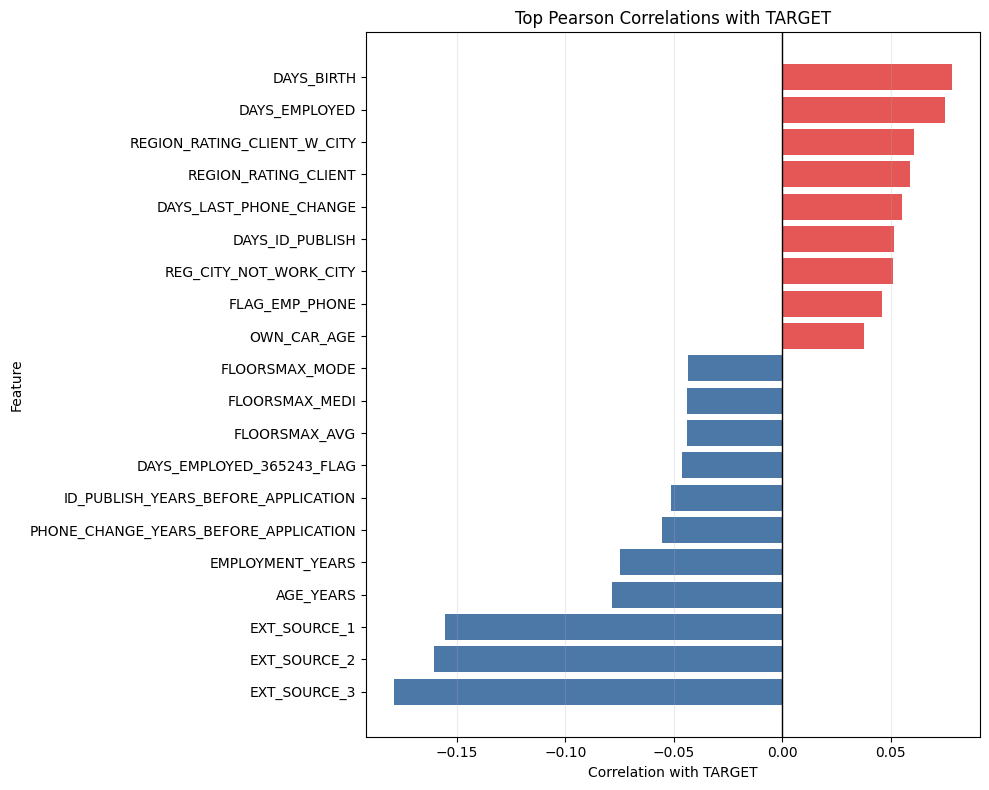

In [59]:
plot_data = correlation_comparison.head(20).sort_values("pearson_correlation")

fig, ax = plt.subplots(figsize=(10, 8))
colors = plot_data["pearson_correlation"].map(lambda value: "#E45756" if value > 0 else "#4C78A8")
ax.barh(plot_data.index, plot_data["pearson_correlation"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Top Pearson Correlations with TARGET")
ax.set_xlabel("Correlation with TARGET")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

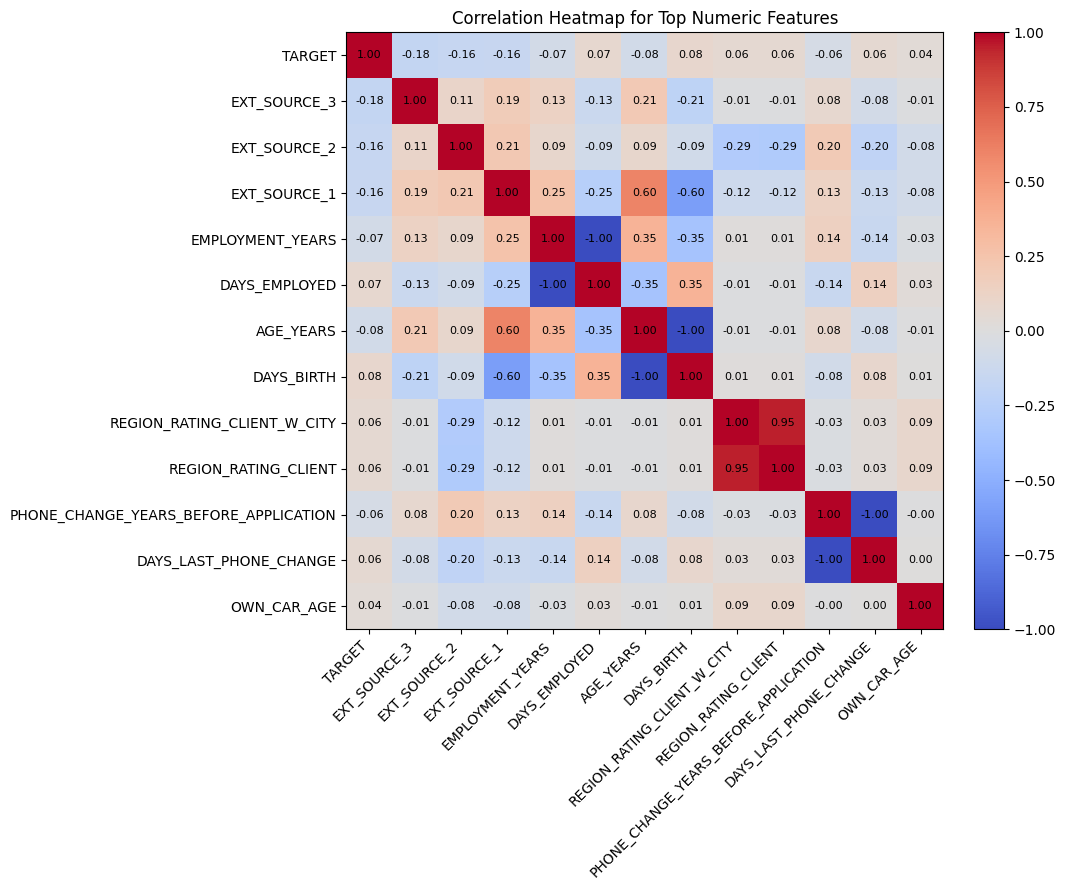

In [60]:
# Heatmap for relationships among the strongest target-correlated numeric features.
top_corr_features = correlation_comparison.head(12).index.tolist()
heatmap_columns = [TARGET] + top_corr_features
heatmap_corr = numeric_for_corr[heatmap_columns].corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(heatmap_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_corr.columns)))
ax.set_xticklabels(heatmap_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_corr.index)))
ax.set_yticklabels(heatmap_corr.index)
ax.set_title("Correlation Heatmap for Top Numeric Features")

for row in range(len(heatmap_corr.index)):
    for col in range(len(heatmap_corr.columns)):
        ax.text(col, row, f"{heatmap_corr.iloc[row, col]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### How To Interpret This

The external source scores usually appear near the top with negative correlations. That means higher external scores are associated with lower default risk.

If two features are highly correlated with each other in the heatmap, they may carry overlapping information. That does not mean one must be removed immediately, but it is useful to know before modeling.

For example, loan amount fields such as `AMT_CREDIT` and `AMT_GOODS_PRICE` may be strongly related because they describe similar loan size information.

## Business Insight Summary

This cell saves the most important Phase 1 findings to a JSON file. It is useful for reports and for checking that the notebook ran successfully.

In [61]:
summary = {
    "rows_analyzed": int(len(df)),
    "columns_analyzed": int(len(df.columns)),
    "default_rate": float(df[TARGET].mean()),
    "top_missing_columns": missing_values.head(15).to_dict(orient="records"),
    "strongest_numeric_correlations": correlations.head(15).reset_index().rename(columns={"index": "column", TARGET: "correlation"}).to_dict(orient="records"),
    "outputs": [
        "dataset_overview.csv",
        "target_distribution.csv",
        "missing_values.csv",
        "categorical_default_rates.csv",
        "numeric_default_summary.csv",
        "numeric_distribution_after_year_conversion.csv",
        "numeric_outlier_summary.csv",
        "phase_1_summary.json",
    ],
}

(OUTPUT_DIR / "phase_1_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(f"Rows analyzed: {summary['rows_analyzed']:,}")
print(f"Columns analyzed: {summary['columns_analyzed']:,}")
print(f"Observed default rate: {summary['default_rate']:.2%}")
print(f"Phase 1 outputs written to: {OUTPUT_DIR}")

Rows analyzed: 307,511
Columns analyzed: 122
Observed default rate: 8.07%
Phase 1 outputs written to: D:\DataScience_project\SCB_intern_project\outputs\phase_1
